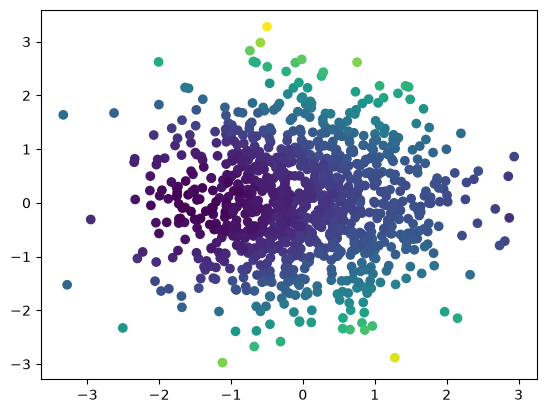

In [16]:
import numpy as np
import matplotlib.pyplot as plt

X = np.random.randn(1000, 2)
y = (np.sin(X[:, [0]]) + 0.75 * X[:, [1]]**2 + 0.1 * np.random.randn(1000, 1))

plt.scatter(X[:, 0], X[:, 1], c=y);

In [47]:
class MultiLayerPerceptron:
    def __init__(self, *dims):
        self.W1 = np.random.randn(dims[0], dims[1]) * 0.01
        self.b1 = np.zeros(dims[1])
        self.W2 = np.random.randn(dims[1], dims[2]) * 0.01
        self.b2 = np.zeros(dims[2])

    def __call__(self, x):
        z1 = x @ self.W1 + self.b1 # ((B, dim1))
        a1 = np.tanh(z1) # (B, dim1)
        z2 = a1 @ self.W2 + self.b2

        return z2
    
    def backward(self, x, y, lr=0.1):
        y = y.reshape(-1, 1)

        z1 = x @ self.W1 + self.b1
        a1 = np.tanh(z1)
        z2 = a1 @ self.W2 + self.b2

        # diffrentiations
        dz2 = (z2 - y) / x.shape[0] # (B, 1)
        dW2 = a1.T @ dz2
        db2 = dz2.sum(axis=0)

        da1 = dz2 @ self.W2.T
        dz1 = (1 - np.tanh(z1)**2) * da1
        dW1 = x.T @ dz1
        db1 = dz1.sum(axis=0)

        self.W2 -= lr * dW2
        self.b2 -= lr * db2
        self.W1 -= lr * dW1
        self.b1 -= lr * db1

        return z2

In [48]:
def loss_fn(logit, y):
    return np.mean(np.linalg.norm(logits - y))

model = MultiLayerPerceptron(2, 4, 1)
epochs = 10000
for epoch in range(epochs):
    logits = model.backward(X, y)
    loss = loss_fn(logits, y)
    print(f"epoch: {epoch+1}, loss: {loss}")

epoch: 1, loss: 45.689037217181
epoch: 2, loss: 44.50434268565786
epoch: 3, loss: 43.52109123609345
epoch: 4, loss: 42.70803344475299
epoch: 5, loss: 42.037883499484586
epoch: 6, loss: 41.48706852893122
epoch: 7, loss: 41.035419302457896
epoch: 8, loss: 40.66582651107859
epoch: 9, loss: 40.363885125255926
epoch: 10, loss: 40.117545104694344
epoch: 11, loss: 39.916781641267846
epoch: 12, loss: 39.753293244576504
epoch: 13, loss: 39.62023191021429
epoch: 14, loss: 39.511966538890654
epoch: 15, loss: 39.42387865955673
epoch: 16, loss: 39.352188196371074
epoch: 17, loss: 39.29380631824474
epoch: 18, loss: 39.24621214214524
epoch: 19, loss: 39.20735007918994
epoch: 20, loss: 39.175544802951215
epoch: 21, loss: 39.14943110171841
epoch: 22, loss: 39.12789619637389
epoch: 23, loss: 39.110032428542624
epoch: 24, loss: 39.09509852944012
epoch: 25, loss: 39.08248795769116
epoch: 26, loss: 39.071703039920315
epoch: 27, loss: 39.06233386059177
epoch: 28, loss: 39.0540410291025
epoch: 29, loss: 39.0

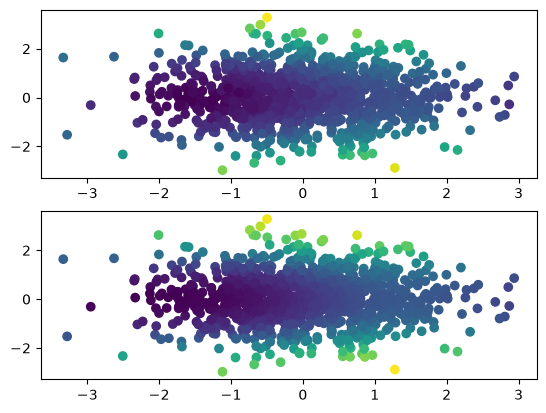

In [50]:
logits = model(X)
fig, axs = plt.subplots(2, 1)
axs = axs.flatten()
axs[0].scatter(X[:, 0], X[:, 1], c=y)
axs[1].scatter(X[:, 0], X[:, 1], c=logits);

In [ ]:
# go on